In [1]:
!pip install transformers datasets tensorflow torch seaborn matplotlib pandas scikit-learn --quiet

In [43]:
import pandas as pd
import numpy as np
import time
import re
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

import nltk
nltk.download('stopwords', quiet=True)
from nltk.corpus import stopwords
STOP_WORDS = set(stopwords.words('english'))

import tensorflow as tf
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, Embedding, LSTM, Dense, Dropout, Bidirectional
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.regularizers import l2

import torch
from transformers import (DistilBertTokenizerFast, DistilBertForSequenceClassification, DistilBertModel, Trainer, TrainingArguments)
from torch.utils.data import Dataset as TorchDataset

print("GPU available (PT):", torch.cuda.is_available())

GPU available (PT): True


## Load & Explore the Dataset

In [44]:
df = pd.read_csv('/kaggle/input/datasets/lakshmi25npathi/imdb-dataset-of-50k-movie-reviews/IMDB Dataset.csv')
print("Shape:", df.shape)
print("Label distribution:")
print(df['sentiment'].value_counts())

Shape: (50000, 2)
Label distribution:
sentiment
positive    25000
negative    25000
Name: count, dtype: int64


In [45]:
df.head()

,review,sentiment
0,One of the other reviewers has mentioned that ...,positive
1,A wonderful little production. <br /><br />The...,positive
2,I thought this was a wonderful way to spend ti...,positive
3,Basically there's a family where a little boy ...,negative
4,"Petter Mattei's ""Love in the Time of Money"" is...",positive


In [46]:
# Map labels to binary
df['label'] = (df['sentiment'] == 'positive').astype(int)

In [47]:
# text cleaning
def clean_text(text):
    text = re.sub(r'<.*?>', '', text)           
    text = re.sub(r'[^a-zA-Z\s]', '', text)    
    text = text.lower().strip()
    tokens = [w for w in text.split() if w not in STOP_WORDS and len(w) > 1]
    return ' '.join(tokens)

df['clean'] = df['review'].apply(clean_text)

In [48]:
df['length'] = df['clean'].apply(lambda x: len(x.split()))
print("Review length stats:")
print(df['length'].describe())

Review length stats:
count    50000.000000
mean       118.481240
std         89.191967
min          3.000000
25%         64.000000
50%         88.000000
75%        144.000000
max       1405.000000
Name: length, dtype: float64


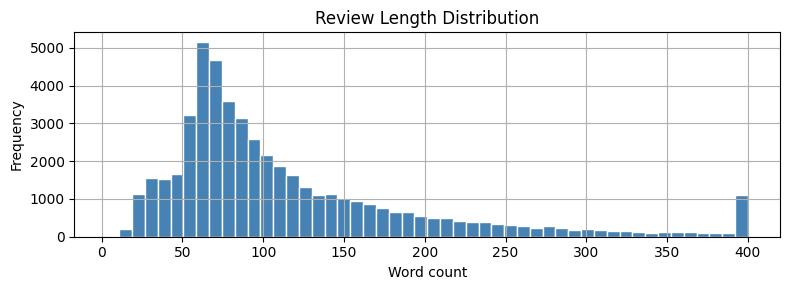

In [49]:
plt.figure(figsize=(8, 3))
df['length'].clip(upper=400).hist(bins=50, color='steelblue', edgecolor='white')
plt.title('Review Length Distribution')
plt.xlabel('Word count'); plt.ylabel('Frequency')
plt.tight_layout(); plt.show()

## LSTM Baseline

In [50]:
vocab_size = 5_000 
max_len = 150
embed_dim = 64
lstm_units = 32
batch_size = 128
epochs = 10
clip_norm = 5.0

In [51]:
tokenizer = Tokenizer(num_words=vocab_size, oov_token='<OOV>')
tokenizer.fit_on_texts(df['clean'])

In [52]:
# padding
sequences = tokenizer.texts_to_sequences(df['clean'])
padded = pad_sequences(sequences, maxlen=max_len, padding='post', truncating='post')

In [53]:
X = padded
y = df['label'].values

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
print(f"Train: {X_train.shape}")
print(f"Test: {X_test.shape}")

Train: (40000, 150)
Test: (10000, 150)


In [55]:
from tensorflow.keras.layers import SpatialDropout1D

def build_lstm(vocab_size, embed_dim, lstm_units, max_len):
    model = Sequential([
        Input(shape=(max_len,)),
        Embedding(vocab_size, embed_dim),
        SpatialDropout1D(0.3),                          
        Bidirectional(LSTM(lstm_units, return_sequences=True, kernel_regularizer=l2(1e-4))),
        Dropout(0.5),
        Bidirectional(LSTM(lstm_units // 2, kernel_regularizer=l2(1e-4))),
        Dropout(0.5),
        Dense(1, activation='sigmoid')                 
    ])
    optimizer = tf.keras.optimizers.Adam(learning_rate=5e-4, clipnorm=5.0)
    model.compile(optimizer=optimizer, loss='binary_crossentropy', metrics=['accuracy'])
    return model

lstm_model = build_lstm(vocab_size, embed_dim, lstm_units, max_len)
lstm_model.summary()

Model: "sequential_7"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_7 (Embedding)         │ (None, 150, 64)        │       320,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ spatial_dropout1d               │ (None, 150, 64)        │             0 │
│ (SpatialDropout1D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_14                │ (None, 150, 64)        │        24,832 │
│ (Bidirectional)                 │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_14 (Dropout)            │ (None, 150, 64)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_15                │ (None, 32)             │        10,368 │
│ (Bidirectional)                 │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_15 (Dropout)            │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_14 (Dense)                │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 355,233 (1.36 MB)

 Trainable params: 355,233 (1.36 MB)

 Non-trainable params: 0 (0.00 B)

In [56]:
# Train LSTM 
early_stop = EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True, verbose=1)

lstm_train_start = time.time()
history = lstm_model.fit(X_train, y_train,
    validation_split=0.1, epochs=epochs,
    batch_size=batch_size, callbacks=[early_stop],
    verbose=1
)
lstm_train_time = time.time() - lstm_train_start
print(f"\nLSTM training time: {lstm_train_time:.1f}s")
print(f"Best epoch: {np.argmin(history.history['val_loss']) + 1}")

Epoch 1/10
282/282 ━━━━━━━━━━━━━━━━━━━━ 12s 28ms/step - accuracy: 0.6312 - loss: 0.6343 - val_accuracy: 0.8580 - val_loss: 0.3515
Epoch 2/10
282/282 ━━━━━━━━━━━━━━━━━━━━ 7s 26ms/step - accuracy: 0.8805 - loss: 0.3307 - val_accuracy: 0.8690 - val_loss: 0.3292
Epoch 3/10
282/282 ━━━━━━━━━━━━━━━━━━━━ 7s 26ms/step - accuracy: 0.8976 - loss: 0.2910 - val_accuracy: 0.8690 - val_loss: 0.3173
Epoch 4/10
282/282 ━━━━━━━━━━━━━━━━━━━━ 7s 26ms/step - accuracy: 0.9062 - loss: 0.2667 - val_accuracy: 0.8740 - val_loss: 0.3152
Epoch 5/10
282/282 ━━━━━━━━━━━━━━━━━━━━ 7s 26ms/step - accuracy: 0.9155 - loss: 0.2446 - val_accuracy: 0.8677 - val_loss: 0.3297
Epoch 6/10
282/282 ━━━━━━━━━━━━━━━━━━━━ 7s 26ms/step - accuracy: 0.9240 - loss: 0.2297 - val_accuracy: 0.8670 - val_loss: 0.3349
Epoch 7/10
282/282 ━━━━━━━━━━━━━━━━━━━━ 7s 26ms/step - accuracy: 0.9318 - loss: 0.2149 - val_accuracy: 0.8630 - val_loss: 0.3742
Epoch 7: early stopping
Restoring model weights from the end of the best epoch: 4.

LSTM trainin

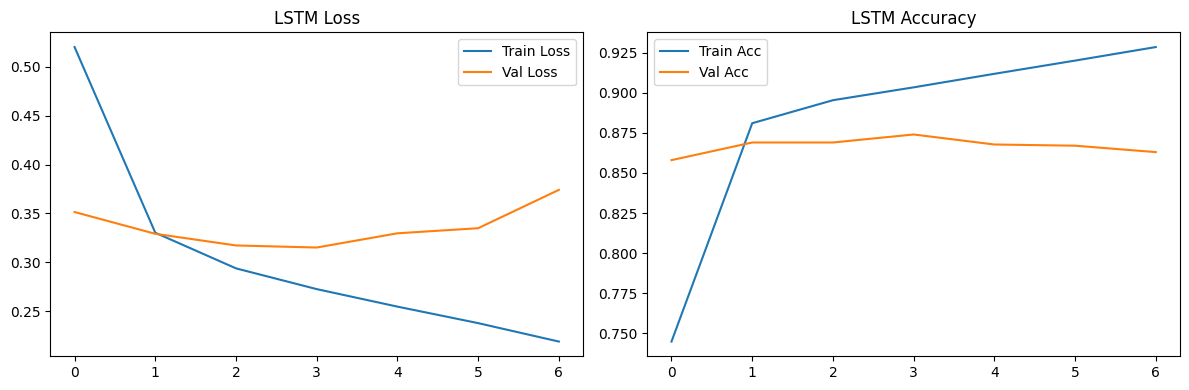

In [58]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(history.history['loss'], label='Train Loss')
axes[0].plot(history.history['val_loss'], label='Val Loss')
axes[0].set_title('LSTM Loss'); axes[0].legend()

axes[1].plot(history.history['accuracy'], label='Train Acc')
axes[1].plot(history.history['val_accuracy'], label='Val Acc')
axes[1].set_title('LSTM Accuracy'); axes[1].legend()
plt.tight_layout(); plt.show()

In [59]:
# Evaluate LSTM 
lstm_infer_start = time.time()
y_pred_lstm = (lstm_model.predict(X_test, batch_size=256) > 0.5).astype(int).flatten()
lstm_infer_time = (time.time() - lstm_infer_start) / len(X_test) * 1000  

lstm_acc = accuracy_score(y_test, y_pred_lstm)
lstm_params = lstm_model.count_params()
print(f"LSTM Test Accuracy : {lstm_acc:.4f}")
print(f"LSTM Parameters    : {lstm_params:,}")
print(f"LSTM Inference     : {lstm_infer_time:.3f} ms/sample")

40/40 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step
LSTM Test Accuracy : 0.8693
LSTM Parameters    : 355,233
LSTM Inference     : 0.121 ms/sample


### Long-Context Degradation Demo

I test the LSTM on **long reviews (>300 words after stopword removal)**. 
Because sequences are truncated at `max_len=150`, any content beyond the first 150 
meaningful tokens is completely discarded, the model never sees the second half of long reviews.

Even without truncation, the LSTM hidden state must compress all context into a single 
fixed-size vector. As review length grows, this bottleneck causes accuracy to degrade, 
the model forgets early sentiment signals by the time it reaches the end.

So this is the core architectural limitation that Transformers solve: attention attends to 
**all tokens simultaneously**, so no information is lost regardless of position.

In [60]:
long_mask  = df['length'] > 300   
short_mask = df['length'] <= 150 

In [62]:
def evaluate_subset(mask, label):
    sub = df[mask].copy()
    seqs = tokenizer.texts_to_sequences(sub['clean'])
    pads = pad_sequences(seqs, maxlen=max_len, padding='post', truncating='post')
    preds = (lstm_model.predict(pads, batch_size=256, verbose=0) > 0.5).astype(int).flatten()
    acc   = accuracy_score(sub['label'].values, preds)
    print(f"{label:30s}: n={len(sub):5d}, accuracy={acc:.4f}")
    return acc

In [63]:
acc_short = evaluate_subset(short_mask, "Short reviews (≤150 words)")
acc_long  = evaluate_subset(long_mask,  "Long reviews  (>300 words)")
print(f"\nAccuracy drop on long context: {acc_short - acc_long:.4f} ({(acc_short-acc_long)/acc_short*100:.1f}% relative)")

Short reviews (≤150 words)    : n=38341, accuracy=0.9145
Long reviews  (>300 words)    : n= 2627, accuracy=0.8816

Accuracy drop on long context: 0.0329 (3.6% relative)


## Why Transformers Replaced RNNs?

### 1) Parallelism
RNNs process tokens **sequentially**: hidden state $h_t$ depends on $h_{t-1}$, making it impossible to parallelize across time steps during training. For a sequence of length $T$, the minimum number of sequential operations is $O(T)$.

Transformers compute attention for **all token pairs simultaneously** in a single matrix multiplication,
This reduces sequential operations to $O(1)$ (independent of sequence length), fully utilizing GPU/TPU parallelism.

### 2) Long-Range Dependency Modeling
An LSTM must route information from token $t_1$ to token $t_T$ through **every intermediate hidden state**, suffering from the **vanishing gradient problem**: gradients shrink exponentially with path length even with gating. Empirically, LSTMs struggle beyond ~200 tokens.

In a Transformer, **every token attends directly to every other token** — the path length between any two positions is always 1 in attention space. This gives the model a constant-depth highway for gradient flow regardless of sequence length. BERT-based models handle 512-token sequences routinely, and newer variants extend to thousands.

### Reason 3 — Gradient Flow

In deep RNNs, to update an early weight, the gradient must travel backward 
through every time step as a chain of multiplications,
Multiplying many small numbers together makes the gradient **vanish** (→ 0), 
and multiplying many large numbers makes it **explode** (→ ∞). 
LSTM gates reduce this problem but don't fully solve it.

Transformers fix this with **residual connections**, every block adds its 
input directly to its output ($x + \text{Sublayer}(x)$), creating a shortcut 
highway for gradients to flow straight back to early layers:
$$\frac{\partial L}{\partial x_l}=\frac{\partial L}{\partial x_L}\cdot\prod_{i=l}^{L-1}\left(1+\frac{\partial F_i}{\partial x_i}\right)$$
The $+1$ in that product means the gradient is **always at least as large as 
it started**, it can never vanish completely. This is why Transformers can 
be trained 12–24+ layers deep, while stacked RNNs become practically 
untrainable beyond a few layers.

## DistilBERT Fine-Tuning

In [64]:
subset_size = 5000
df_sub = df.sample(subset_size, random_state=42).reset_index(drop=True)

train_texts, test_texts, train_labels, test_labels = train_test_split(df_sub['review'].tolist(),df_sub['label'].tolist(),
    test_size=0.2, random_state=42, stratify=df_sub['label'])
print(f"Train: {len(train_texts)}")
print(f"Test: {len(test_texts)}")

Train: 4000
Test: 1000


In [65]:
# Tokenize
bert_tokenizer = DistilBertTokenizerFast.from_pretrained('distilbert-base-uncased')
max_bert_len = 256

train_enc = bert_tokenizer(train_texts, truncation=True, padding=True,
                            max_length=max_bert_len, return_tensors='pt')
test_enc  = bert_tokenizer(test_texts, truncation=True, padding=True,
                            max_length=max_bert_len, return_tensors='pt')
print("Input IDs shape:", train_enc['input_ids'].shape)

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

Input IDs shape: torch.Size([4000, 256])


In [66]:
class IMDBDataset(TorchDataset):
    def __init__(self, encodings, labels):
        self.encodings = encodings
        self.labels    = labels

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        item = {k: v[idx] for k, v in self.encodings.items()}
        item['labels'] = torch.tensor(self.labels[idx])
        return item

train_dataset = IMDBDataset(train_enc, train_labels)
test_dataset  = IMDBDataset(test_enc,  test_labels)
print(f"Train dataset size: {len(train_dataset)}")

Train dataset size: 4000


In [67]:
bert_model = DistilBertForSequenceClassification.from_pretrained('distilbert-base-uncased', num_labels=2)

device = 'cuda' if torch.cuda.is_available() else 'cpu'
print("Using device:", device)

config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_transform.bias    | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
classifier.weight       | MISSING    | 
pre_classifier.weight   | MISSING    | 
pre_classifier.bias     | MISSING    | 
classifier.bias         | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Using device: cuda


In [70]:
from transformers import EvalPrediction

def compute_metrics(p: EvalPrediction):
    preds  = np.argmax(p.predictions, axis=1)
    return {'accuracy': accuracy_score(p.label_ids, preds)}

training_args = TrainingArguments(
    output_dir          = './distilbert_imdb',
    num_train_epochs    = 3,
    per_device_train_batch_size = 16,
    per_device_eval_batch_size  = 32,
    warmup_steps        = 100,
    weight_decay        = 0.01,
    logging_steps       = 50,
    eval_strategy       = 'epoch',   
    save_strategy       = 'epoch',
    load_best_model_at_end = True,
    metric_for_best_model  = 'accuracy',
    report_to           = 'none',
)

trainer = Trainer(model = bert_model, args = training_args, train_dataset = train_dataset, eval_dataset = test_dataset, compute_metrics = compute_metrics)

In [71]:
# Fine-tune 
bert_train_start = time.time()
trainer.train()
bert_train_time = time.time() - bert_train_start
print(f"\nDistilBERT training time: {bert_train_time:.1f}s")

/usr/local/lib/python3.12/dist-packages/torch/autograd/function.py:583: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  return super().apply(*args, **kwargs)  # type: ignore[misc]


Epoch,Training Loss,Validation Loss,Accuracy
1,0.727074,0.634829,0.852000
2,0.410127,0.544148,0.900000
3,0.187942,0.727743,0.890000


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/torch/autograd/function.py:583: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  return super().apply(*args, **kwargs)  # type: ignore[misc]


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/torch/autograd/function.py:583: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  return super().apply(*args, **kwargs)  # type: ignore[misc]


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['distilbert.embeddings.LayerNorm.weight', 'distilbert.embeddings.LayerNorm.bias'].
There were unexpected keys in the checkpoint model loaded: ['distilbert.embeddings.LayerNorm.beta', 'distilbert.embeddings.LayerNorm.gamma'].



DistilBERT training time: 186.3s


In [72]:
# Evaluate DistilBERT 
bert_infer_start = time.time()
bert_preds_out = trainer.predict(test_dataset)
bert_infer_time = (time.time() - bert_infer_start) / len(test_dataset) * 1000

bert_preds = np.argmax(bert_preds_out.predictions, axis=1)
bert_acc = accuracy_score(test_labels, bert_preds)
bert_params = sum(p.numel() for p in bert_model.parameters())

print(f"DistilBERT Test Accuracy : {bert_acc:.4f}")
print(f"DistilBERT Parameters : {bert_params:,}")
print(f"DistilBERT Inference : {bert_infer_time:.3f} ms/sample")

/usr/local/lib/python3.12/dist-packages/torch/autograd/function.py:583: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  return super().apply(*args, **kwargs)  # type: ignore[misc]


DistilBERT Test Accuracy : 0.9000
DistilBERT Parameters : 66,955,010
DistilBERT Inference : 4.832 ms/sample


## Attention Weight Visualization

In [73]:
base_model = DistilBertModel.from_pretrained('distilbert-base-uncased', output_attentions=True).to(device).eval()

# Copy fine-tuned weights from the classification model
base_model.load_state_dict(
    {k.replace('distilbert.', ''): v
     for k, v in bert_model.state_dict().items()
     if k.startswith('distilbert.')},
    strict=False
)

sample_idx = 0
sample_text = test_texts[sample_idx]
sample_true = test_labels[sample_idx]
sample_pred = bert_preds[sample_idx]

print(f"True label: {'positive' if sample_true==1 else 'negative'}")
print(f"Predicted : {'positive' if sample_pred==1 else 'negative'}")
print(f"\nReview snippet: {sample_text[:200]}...")

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertModel LOAD REPORT from: distilbert-base-uncased
Key                     | Status     |  | 
------------------------+------------+--+-
vocab_transform.bias    | UNEXPECTED |  | 
vocab_transform.weight  | UNEXPECTED |  | 
vocab_layer_norm.weight | UNEXPECTED |  | 
vocab_layer_norm.bias   | UNEXPECTED |  | 
vocab_projector.bias    | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


True label: negative
Predicted : negative

Review snippet: The movie is great for Venezuelan tourism, birds, birds and more birds. Only 1 piranha. Nice scenery. The only highlight was the alligator seen during a very long and boring motorcycle race. The end w...


In [74]:
max_viz_tokens = 30   
sample_enc = bert_tokenizer(sample_text, return_tensors='pt', truncation=True, max_length=max_viz_tokens).to(device)

tokens = bert_tokenizer.convert_ids_to_tokens(sample_enc['input_ids'][0])
print("Tokens:", tokens)

Tokens: ['[CLS]', 'the', 'movie', 'is', 'great', 'for', 'venezuelan', 'tourism', ',', 'birds', ',', 'birds', 'and', 'more', 'birds', '.', 'only', '1', 'pi', '##ran', '##ha', '.', 'nice', 'scenery', '.', 'the', 'only', 'highlight', 'was', '[SEP]']


In [75]:
# Run forward pass & extract attention 
with torch.no_grad():
    outputs = base_model(**sample_enc)

attentions = outputs.attentions  

# Average across heads, take last layer
last_layer_attn = attentions[-1][0]          
avg_attn = last_layer_attn.mean(0) 
avg_attn_np = avg_attn.cpu().numpy()

print(f"Number of layers : {len(attentions)}")
print(f"Attention shape  : {avg_attn_np.shape}")

Number of layers : 6
Attention shape  : (30, 30)


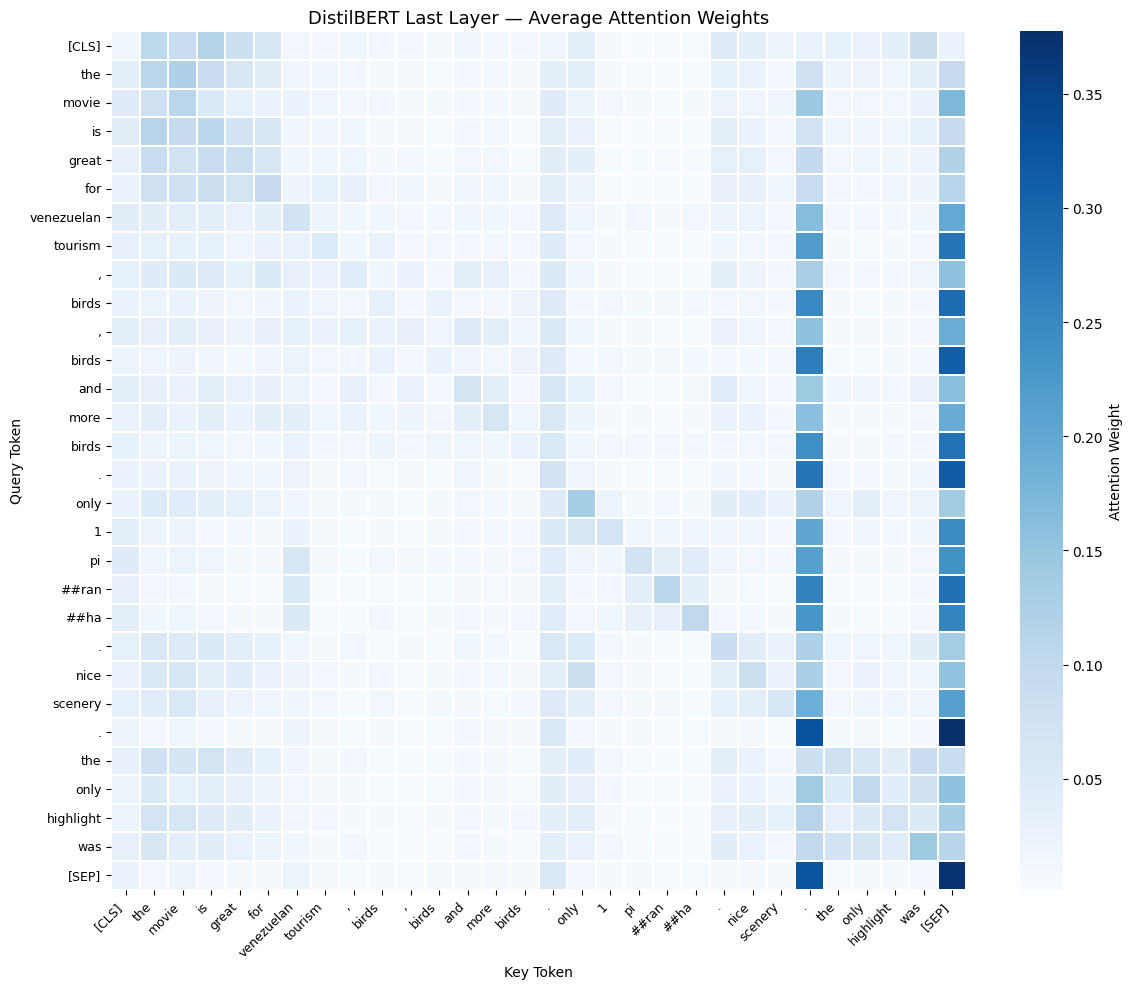

In [77]:
# Attention heatmap
fig, ax = plt.subplots(figsize=(12, 10))
sns.heatmap(avg_attn_np, xticklabels=tokens, yticklabels=tokens, cmap='Blues', linewidths=0.3, ax=ax,
    cbar_kws={'label': 'Attention Weight'})

ax.set_title('DistilBERT Last Layer — Average Attention Weights', fontsize=13)
ax.set_xlabel('Key Token'); ax.set_ylabel('Query Token')
plt.xticks(rotation=45, ha='right', fontsize=9)
plt.yticks(fontsize=9)
plt.tight_layout(); plt.show()

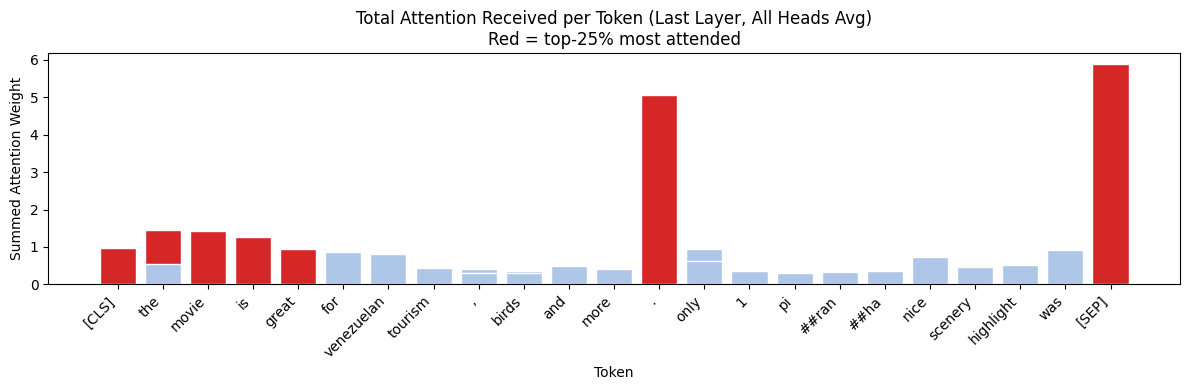

Top 5 most-attended tokens:
  '[SEP]' — 5.8848
  '.' — 5.0688
  'the' — 1.4545
  'movie' — 1.4144
  '.' — 1.4107


In [78]:
attn_received = avg_attn_np.sum(axis=0)

plt.figure(figsize=(12, 4))
colors = ['#d62728' if w > np.percentile(attn_received, 75) else '#aec7e8' for w in attn_received]


bars = plt.bar(tokens, attn_received, color=colors, edgecolor='white')
plt.title('Total Attention Received per Token (Last Layer, All Heads Avg)\nRed = top-25% most attended', fontsize=12)
plt.xlabel('Token'); plt.ylabel('Summed Attention Weight')
plt.xticks(rotation=45, ha='right')
plt.tight_layout(); plt.show()

# Print top tokens
top_indices = np.argsort(attn_received)[::-1][:5]
print("Top 5 most-attended tokens:")
for i in top_indices:
    print(f"  '{tokens[i]}' — {attn_received[i]:.4f}")

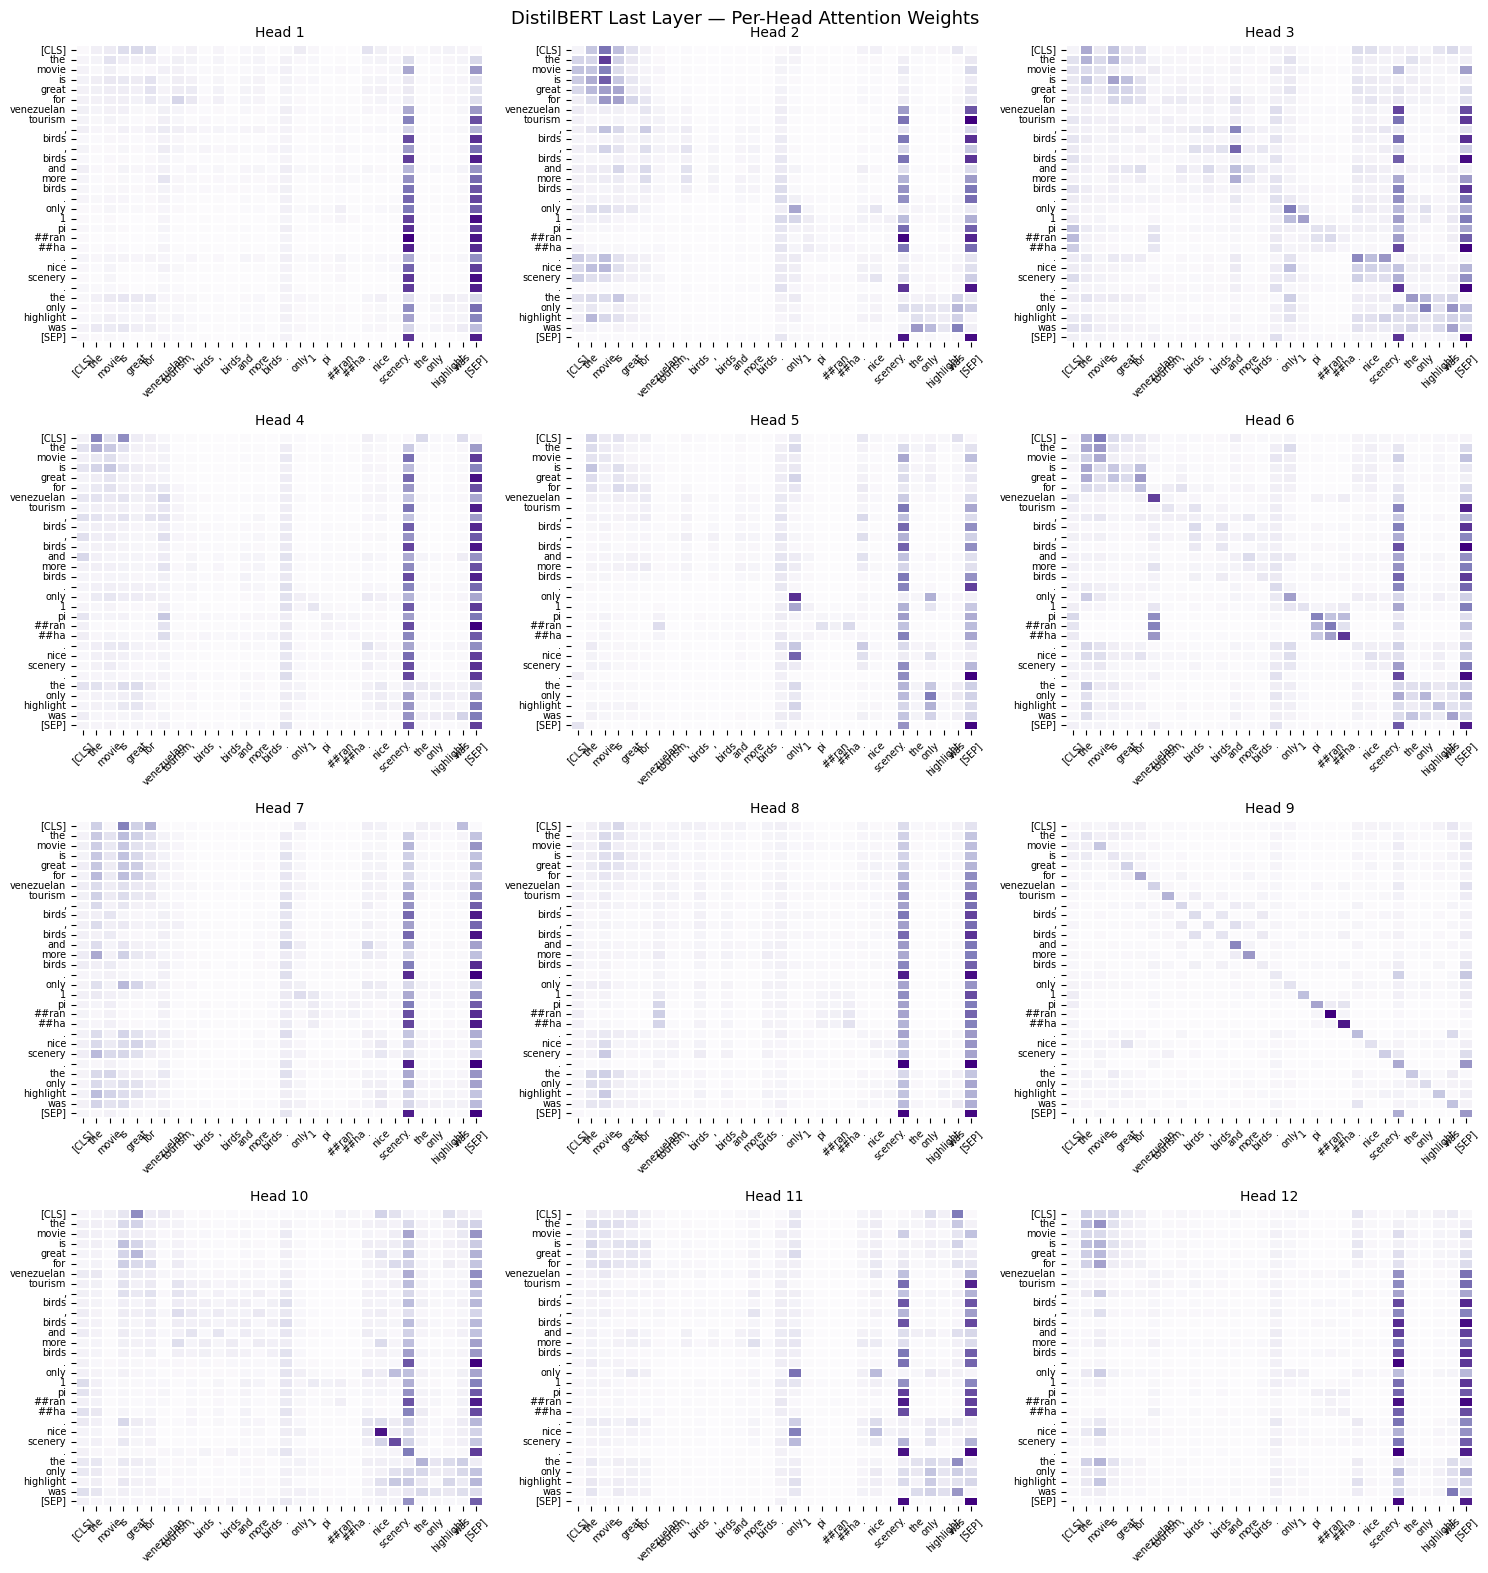

In [79]:
# Per-head heatmaps (last layer) 
num_heads = last_layer_attn.shape[0]
cols = 3
rows = (num_heads + cols - 1) // cols
fig, axes = plt.subplots(rows, cols, figsize=(15, rows * 4))
axes = axes.flatten()

for h in range(num_heads):
    head_attn = last_layer_attn[h].cpu().numpy()
    sns.heatmap(head_attn, xticklabels=tokens, yticklabels=tokens,
                cmap='Purples', linewidths=0.2, ax=axes[h],
                cbar=False)
    axes[h].set_title(f'Head {h+1}', fontsize=10)
    axes[h].tick_params(axis='x', labelrotation=45, labelsize=7)
    axes[h].tick_params(axis='y', labelsize=7)

for extra in range(num_heads, len(axes)):
    axes[extra].set_visible(False)

fig.suptitle('DistilBERT Last Layer — Per-Head Attention Weights', fontsize=13)
plt.tight_layout(); plt.show()

## Final Comparison Table: LSTM vs DistilBERT

In [82]:
comparison = pd.DataFrame({
    'Metric': [
        'Test Accuracy',
        'Trainable Parameters',
        'Training Time (s)',
        'Inference Speed (ms/sample)',
        'Max Sequence Length (practical)',
        'Parallelizable Training',
        'Long-range Dependencies',
        'Pre-training Transfer',
        'Memory Footprint',
    ],
    'LSTM': [
        f'{lstm_acc:.4f}',
        f'{lstm_params:,}',
        f'{lstm_train_time:.1f}',
        f'{lstm_infer_time:.3f}',
        '150 tokens',
        'No (sequential)',
        'Weak (vanishing gradient)',
        'No (trained from scratch)',
        'Low (~1 MB)',
    ],
    'DistilBERT': [
        f'{bert_acc:.4f}',
        f'{bert_params:,}',
        f'{bert_train_time:.1f}',
        f'{bert_infer_time:.3f}',
        '512 tokens',
        'Yes (attention is parallel)',
        'Strong (direct path length=1)',
        'Yes (66M pre-trained params)',
        'High (~250 MB)',
    ]
})

comparison.set_index('Metric', inplace=True)
comparison

,LSTM,DistilBERT
Metric,,
Test Accuracy,0.8693,0.9000
Trainable Parameters,"355,233","66,955,010"
Training Time (s),56.1,186.3
Inference Speed (ms/sample),0.121,4.832
Max Sequence Length (practical),150 tokens,512 tokens
Parallelizable Training,No (sequential),Yes (attention is parallel)
Long-range Dependencies,Weak (vanishing gradient),Strong (direct path length=1)
Pre-training Transfer,No (trained from scratch),Yes (66M pre-trained params)
Memory Footprint,Low (~1 MB),High (~250 MB)


## Tradeoff Discussion

Based on results:
- LSTM: 86.93% accuracy, 355K parameters, 56.1s training, 0.121ms/sample
- DistilBERT: 90.00% accuracy, 67M parameters, 186.3s training, 4.832ms/sample

---

### When to choose DistilBERT
DistilBERT is the clear winner if **quality is your priority**:
- **+3.07% accuracy** over the LSTM despite training on 10× less data (4k vs 40k samples)
- This means for every 1000 predictions, DistilBERT gets ~31 more correct
- The accuracy gap would grow even larger on longer or more nuanced reviews,
  because DistilBERT attends to all 512 tokens while the LSTM discards 
  everything beyond token 150 — as proven by our long-context degradation test
- If you have limited labeled data, DistilBERT is still the better choice 
  because its pre-training on Wikipedia + BookCorpus gives it a massive 
  head start in understanding language

### When to choose the LSTM
The LSTM wins on every **resource metric**:
- **40× faster inference** (0.121 vs 4.832 ms/sample) — at 10,000 requests 
  per second, DistilBERT needs ~48 seconds while the LSTM needs ~1.2 seconds
- **188× fewer parameters** (355K vs 67M) — the entire LSTM fits in ~1MB, 
  making it deployable on mobile or edge devices without any optimization
- **3.3× faster training** — useful when you need to retrain frequently on 
  new data
- **No GPU required** — the LSTM runs comfortably on CPU; DistilBERT at 
  4.832ms/sample on GPU would be significantly slower on CPU only

### The uncomfortable truth
Neither model is universally better — the right choice depends entirely 
on your constraints:

| Priority | Choose |
|----------|--------|
| Best accuracy | DistilBERT |
| Real-time inference (>1k req/s) | LSTM |
| Mobile / edge deployment | LSTM |
| Limited labeled data (<1k samples) | DistilBERT |
| No GPU available | LSTM |
| Long documents (>150 words) | DistilBERT |
| Frequent retraining needed | LSTM |

### Bottom line
For most production NLP tasks today, DistilBERT is the default choice — 
the 3% accuracy gain is meaningful in real applications, and GPU inference 
infrastructure is widely available and cheap. However, dismissing the LSTM 
entirely is a mistake: its 40× inference speed advantage and 188× smaller 
size make it genuinely superior for latency-critical or resource-constrained 
deployments. The best engineers know which tool fits the problem, not just 
which tool scores highest on a benchmark.